In [1]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

import matplotlib.pyplot as plt

from cubes import set_r_cube
from generate_kolmogorov import get_iso_cube

In [2]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side
k_min = 2*np.pi/(2*L)  # [pc-1], full wavelength in the cube
print(f"Each cell is a cube with size {dx:.2f} pc")
print(f"Injection scale corresponds to {2*np.pi/k_min:.2f} pc")

Each cell is a cube with size 2.34 pc
Injection scale corresponds to 600.00 pc


In [3]:
r_cube = set_r_cube(n_side, L)

In [4]:
b_cube = get_iso_cube(n_side, L, power_index=11/3, k_min=k_min)

In [5]:
class PeriodicInterpolator:
    """Linear interpolator for 3D cubes with periodic boundary conditions"""
    def __init__(self, r_cube, B_cube):
        self.origin = r_cube[0, 0, 0, :]
        self.dx = r_cube[1, 0, 0, 0] - r_cube[0, 0, 0, 0]

        self.N = r_cube.shape[1]
        self.L = self.N * self.dx

        grid = self.origin[..., 0] + np.arange(self.N + 1) * self.dx

        # Add periodic endpoint to each axis [-N dx, (N-1)dx] -> [-Ndx, Ndx]
        B_periodic = B_cube
        B_periodic = np.concatenate(
            [B_periodic, B_periodic[:1, :, :, :]], axis=0
        )
        B_periodic = np.concatenate(
            [B_periodic, B_periodic[:, :1, :, :]], axis=1
        )
        B_periodic = np.concatenate(
            [B_periodic, B_periodic[:, :, :1, :]], axis=2
        )

        self.interp = [
            RegularGridInterpolator(
                (grid, grid, grid),
                B_periodic[..., i],
                method="linear",
                bounds_error=True,
            )
            for i in range(3)
        ]

    def __call__(self, x):
        """
        x : (M, 3)
        returns : (M, 3)
        """

        x = self.origin + np.mod(x - self.origin, self.L)

        B = np.empty_like(x)

        for i in range(3):
            B[:, i] = self.interp[i](x)

        return B

In [6]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube)

In [7]:
ds = dx / 5
n_steps = int(L / ds)  # n_steps

In [8]:
def rk4_step(x, ds, interp):
    """
    Vectorized realization of the classic Runge-Kutta (RK4) step
    https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods#The_Runge%E2%80%93Kutta_method
    
    :param x: (nvec, shape) current integration step
    :param ds: (float)
    :param interp: (callable) interpolated cube
    :return: (nvec, shape) next integration step
    """
    
    def norm(t):
        return np.linalg.norm(t, axis=1, keepdims=True)
    
    k1 = interp(x)
    k1 /= norm(k1)

    k2 = interp(x + 0.5 * ds * k1)
    k2 /= norm(k2)

    k3 = interp(x + 0.5 * ds * k2)
    k3 /= norm(k3)

    k4 = interp(x + ds * k3)
    k4 /= norm(k4)

    return x + ds / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

In [9]:
def integrate_lines(interp, M, n_steps, ds):
    rng = np.random.default_rng()

    x = rng.uniform(
        interp.origin,
        interp.origin + interp.L,
        size=(M, 3),
    )

    lines = np.empty((2 * n_steps + 1, M, 3))

    lines[n_steps] = x

    for i in range(n_steps, 2 * n_steps):
        x = rk4_step(x, ds, interp)
        lines[i + 1] = x
    
    x = lines[n_steps]
    for i in range(n_steps, 0, -1):
        x = rk4_step(x, -ds, interp)
        lines[i - 1] = x

    return lines

In [10]:
M = 1000
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)

In [11]:
def unwrap_lines(lines, box_size):
    unwrapped = lines.copy()

    for i in range(1, len(lines)):
        delta = unwrapped[i] - unwrapped[i-1]

        delta[delta >  box_size/2] -= box_size
        delta[delta < -box_size/2] += box_size

        unwrapped[i] = unwrapped[i-1] + delta

    return unwrapped

In [12]:
import numpy as np
import matplotlib.pyplot as plt


def plot_field_lines(lines, n_lines=20, box_size=None):
    """
    Plot magnetic field lines.

    Parameters
    ----------
    lines : ndarray
        Shape (n_steps, M, 3)
    n_lines : int
        Number of lines to plot
    box_size : float, optional
        Size of periodic box
    """

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    M = lines.shape[1]

    indices = np.random.choice(M, size=min(n_lines, M), replace=False)
    
    n_center = lines.shape[0] // 2

    for i in indices:
        x = lines[:, i, 0]
        y = lines[:, i, 1]
        z = lines[:, i, 2]

        ax.plot(x, y, z, linewidth=1)
        
        # Starting point
        ax.scatter(
            x[n_center],
            y[n_center],
            z[n_center],
            s=20
        )

    if box_size is not None:
        ax.set_xlim(-box_size, box_size)
        ax.set_ylim(-box_size, box_size)
        ax.set_zlim(-box_size, box_size)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.set_box_aspect([1, 1, 1])

    plt.tight_layout()
    plt.show()

In [13]:
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

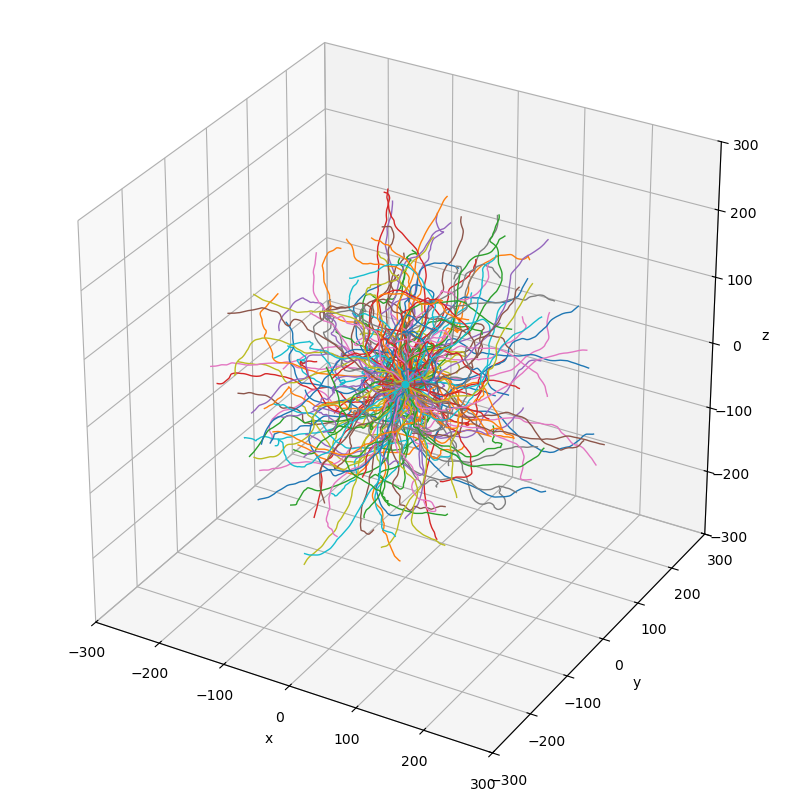

In [14]:
plot_field_lines(
    lines_from_zero,
    n_lines=100,
    box_size=L
)

## Cross-checks

In [15]:
fields = np.zeros_like(lines)
for m in range(M):
    fields[:, m, :] = periodic_interpolator(lines[:, m, :])

In [16]:
B = np.linalg.norm(fields, axis=-1)

In [17]:
mean_all = np.mean(np.linalg.norm(b_cube, axis=-1))
print(mean_all)

0.9163109266928691


In [18]:
mean_fields = np.mean(B)
print(mean_fields)
print(1/mean_all)

1.0240414315097892
1.0913326152392178
